In [2]:
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import scdia as sd

# set data and figure dir
data_dir = '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/'
fig_dir = 'SCP_Microglia/figures/1_5_clustering/'
results_dir = 'SCP_Microglia/results/1_5_clustering/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

sc.settings.verbosity = 3

In [3]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

In [3]:
adata_maxlfq_batch_corrected = sc.read_h5ad('SCP_Microglia/results/1_4_batch_correction/scp_MG_1c_maxlfq_npcs_20_batch_corrected.h5ad')

In [6]:
adata_maxlfq_batch_corrected

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'age_colors', 'bbknn', 'brain_region_colors', 'column_id_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'prepare_date_colors', 'umap'
    obsm: 'CCA', 'Combat', 'FastMNN', 'Harmony', 'Liger', 'RPCA', 'Scanorama', 'X_pca', 'X_umap', 'scPROTEIN', 'scPROTEIN_PCA', 'scVI_nb', 'scVI_normal'
    varm: 'PCs'
    layers: 'log2_total_normalized', 'log2_total_normalized_fc_nan', 'raw_matrix'
    obsp: 'bbknn_conne

### Test BBKNN

In [7]:
adata_maxlfq_corrected_bbknn = adata_maxlfq_batch_corrected.copy()
adata_maxlfq_corrected_bbknn.uns['neighbors'] = adata_maxlfq_corrected_bbknn.uns['bbknn']
adata_maxlfq_corrected_bbknn.obsp['connectivities'] = adata_maxlfq_corrected_bbknn.obsp['bbknn_connectivities']
adata_maxlfq_corrected_bbknn.obsp['distances'] = adata_maxlfq_corrected_bbknn.obsp['bbknn_distances']

In [8]:
sc.tl.leiden(adata_maxlfq_corrected_bbknn, resolution=0.3, key_added='bbknn_leiden_clusters')

running Leiden clustering
    finished: found 5 clusters and added
    'bbknn_leiden_clusters', the cluster labels (adata.obs, categorical) (0:00:00)


In [9]:
sc.tl.umap(adata_maxlfq_corrected_bbknn, min_dist=0.3, spread=1.0) # min_dist=0.3 for a less compact visualization

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


In [10]:
adata_maxlfq_batch_corrected.obsm['bbknn_umap'] = adata_maxlfq_corrected_bbknn.obsm['X_umap']
adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters'] = adata_maxlfq_corrected_bbknn.obs['bbknn_leiden_clusters']

### Use CCA
We ultimately decided to use CCA because of its outstanding performance in removing impurities across both batches; although Liger had a slight advantage in terms of prepare date, but in column id CCA's performace is outstanding.

In [11]:
sc.pp.neighbors(adata_maxlfq_batch_corrected, use_rep='CCA', n_neighbors=25) # use n_neighbors=25 to aviod getting too many clusters

sc.tl.leiden(adata_maxlfq_batch_corrected, resolution=0.25, key_added='cca_leiden_clusters') 

sc.tl.umap(adata_maxlfq_batch_corrected, min_dist=0.5, spread=1.0) # min_dist=0.5 for a less compact visualization

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
running Leiden clustering
    finished: found 6 clusters and added
    'cca_leiden_clusters', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


In [12]:
adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'] = adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].replace({'5' : '3'})

In [13]:
# remap cluster labels
cca_leiden_mapping = {
    '0': '2',
    '1': '3',
    '2': '1',
    '3': '4',
    '4': '5'
}

bbknn_leiden_mapping = {
    '0': '3',
    '1': '2',
    '2': '1',
    '3': '4',
    '4': '5'
}

adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'] = adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].map(cca_leiden_mapping)
adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'] = adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].astype('category')

adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters'] = adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters'].map(bbknn_leiden_mapping)
adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters'] = adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters'].astype('category')

In [14]:
# set cluster order
cluster_order = ['1', '2', '3', '4', '5']
adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'] = adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].cat.reorder_categories(cluster_order, ordered=True)
adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters'] = adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters'].cat.reorder_categories(cluster_order, ordered=True)

In [15]:
adata_maxlfq_batch_corrected.write_h5ad(results_dir + "scp_MG_1c_maxlfq_final_version.h5ad", compression='gzip')

### Figures

In [17]:
adata_maxlfq_batch_corrected = sc.read_h5ad(results_dir + "scp_MG_1c_maxlfq_final_version.h5ad")

In [18]:
adata_maxlfq_batch_corrected.obsm['cca_umap'] = adata_maxlfq_batch_corrected.obsm['X_umap'].copy()

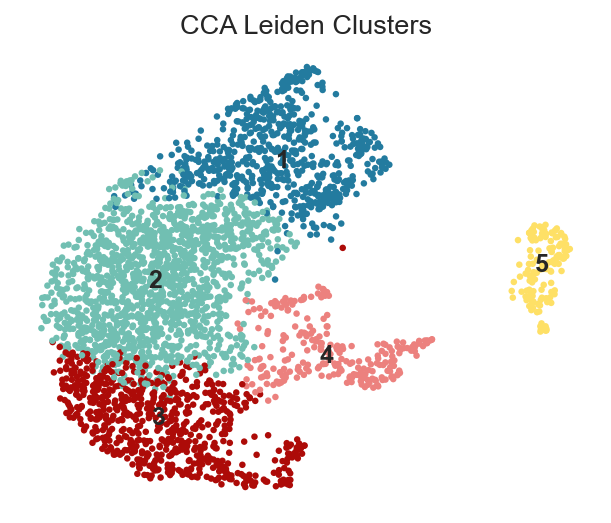

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
sc.pl.umap(
    adata_maxlfq_batch_corrected,
    color='cca_leiden_clusters',
    frameon=False,
    palette=['#237B9F', '#71BFB2', '#AD0B08', '#EC817E', '#FEE066'],
    show=False,
    ax=ax,
    legend_loc='on data',
    legend_fontsize=12,
)
ax.set_title('CCA Leiden Clusters', fontsize=13)

plt.savefig(fig_dir + "umap_cca_leiden_clusters.pdf", dpi=300, bbox_inches='tight')

In [24]:
plot_cmaps = {
    'log2_total_intensity': 'cividis',
    'n_genes_detected': 'cividis',
    'Mrc1': 'viridis',
    'P2ry12': 'viridis',
}

plot_color_palettes = {
    'prepare_date': ["#3e608d", "#4e1945", "#8cbf87", "#8d2f25", "#909291", "#cb9475"],
    'column_id': ["#85D0FF", "#C2C48D", "#FFDC8E"],
    'brain_region': ["#ACD6EC", "#F5A889"],
    'age': ["#000000", "#2C939A", "#A6A3A4"],
}

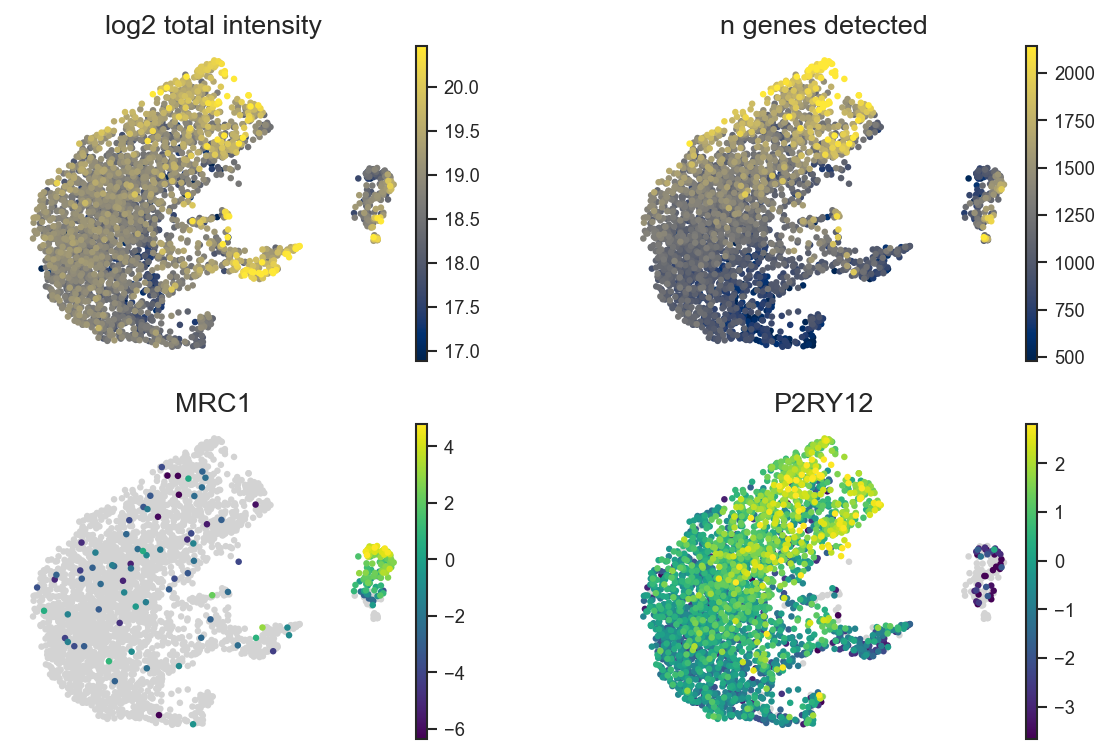

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes = axes.flatten()

for i, parameter in enumerate(plot_cmaps.keys()):
    cmap = plot_cmaps.get(parameter, None)
    palette = plot_color_palettes.get(parameter, None)
    sc.pl.umap(
        adata_maxlfq_batch_corrected,
        color=parameter,
        cmap=cmap,
        palette=palette,
        show=False,
        frameon=False,
        title=None,
        ax=axes[i],
        vmin='p1',
        vmax='p99',
        layer='log2_total_normalized_fc_nan' if parameter in ['Mrc1', 'P2ry12'] else None
    )
    axes[i].set_title(" ".join(parameter.split('_')).upper() if parameter in ['Mrc1', 'P2ry12'] else " ".join(parameter.split('_')), fontsize=13)

plt.subplots_adjust(wspace=0.4, hspace=0.2)
plt.savefig(fig_dir + 'umap_cca_by_continual_parameters.pdf', bbox_inches='tight')

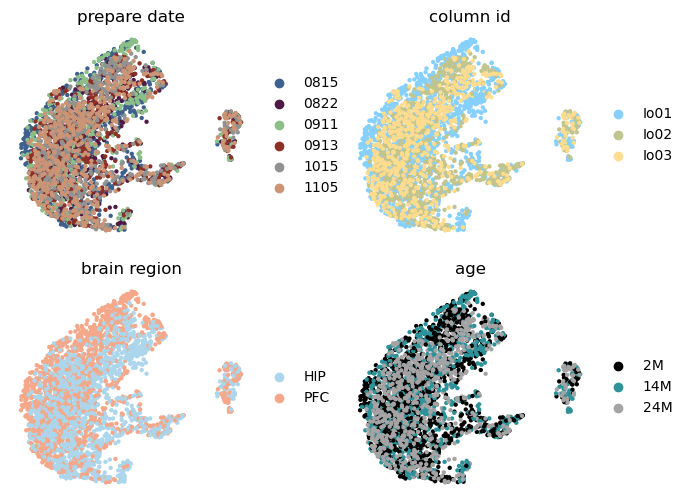

In [23]:
fig = plt.figure(figsize=(7.5, 6))

for i, parameter in enumerate(plot_color_palettes.keys()):
    ax = plt.subplot(2, 2, i+1)
    cmap = plot_cmaps.get(parameter, None)
    palette = plot_color_palettes.get(parameter, None)
    sc.pl.umap(
        adata_maxlfq_batch_corrected,
        color=parameter,
        cmap=cmap,
        palette=palette,
        show=False,
        frameon=False,
        title=" ".join(parameter.split('_')),
        ax=ax,
        vmin='p1',
        vmax='p99',
        layer='log2_total_normalized_fc_nan' if parameter in ['Mrc1', 'P2ry12'] else None
    )

plt.subplots_adjust(wspace=0.4, hspace=0.2)
plt.savefig(fig_dir + 'umap_cca_by_categorical_parameters.pdf', bbox_inches='tight')

In [5]:
print(pd.crosstab(adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'], adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters']))

bbknn_leiden_clusters    1    2    3    4   5
cca_leiden_clusters                          
1                      473  177    2    0   0
2                       72  779  503   15   0
3                        0   14  614   36   0
4                       22   67   22  136   1
5                       15   12   22    0  86


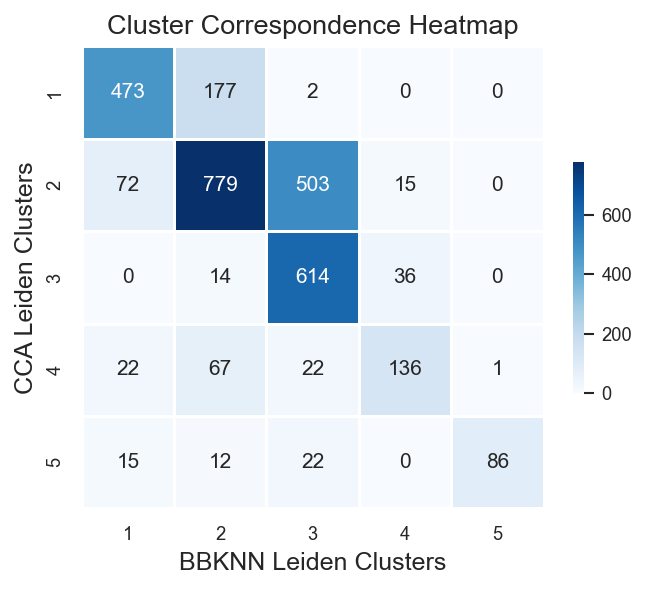

In [23]:
correspondence_df = pd.crosstab(
    adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'], 
    adata_maxlfq_batch_corrected.obs['bbknn_leiden_clusters']
)

fig, ax = plt.subplots(figsize=(5, 4))

g = sns.heatmap(
    correspondence_df, 
    annot=True,               
    fmt='d',                  
    cmap='Blues',            
    linewidths=0.5,           
    linecolor='white',       
    square=True,             
    annot_kws={'size': 10},  
    cbar_kws={'shrink': 0.5}, 
    ax=ax
)

g.set_xlabel('BBKNN Leiden Clusters', fontsize=12)
g.set_ylabel('CCA Leiden Clusters', fontsize=12)
g.set_title('Cluster Correspondence Heatmap', fontsize=13)

g.tick_params(bottom=False, left=False)

plt.savefig(fig_dir + 'cluster_correspondence_heatmap.pdf', dpi=300, bbox_inches='tight')

In [28]:
print(pd.crosstab(adata_maxlfq_batch_corrected.obs['age'], adata_maxlfq_batch_corrected.obs['brain_region']))

brain_region  HIP  PFC
age                   
2M            567  567
14M           435  469
24M           609  421


In [29]:
print(adata_maxlfq_batch_corrected.obs.bbknn_leiden_clusters.value_counts())

bbknn_leiden_clusters
3    1163
2    1049
1     582
4     187
5      87
Name: count, dtype: int64


In [31]:
adata_maxlfq_batch_corrected

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter', 'bbknn_leiden_clusters', 'cca_leiden_clusters'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'cca_leiden_clusters_colors'
    obsm: 'CCA', 'Combat', 'FastMNN', 'Harmony', 'Liger', 'RPCA', 'Scanorama', 'X_pca', 'X_umap', 'bbknn_umap', 'scPROTEIN', 'scPROTEIN_PCA', 'scVI_nb', 'scVI_normal', 'cca_umap'
    varm: 'PCs'
    layers: 'log2_total_normalized', 'log2_total_normalized_fc_nan', 'raw_matrix'
    obsp: 'bbknn_connectivities', 'bbknn_distances'

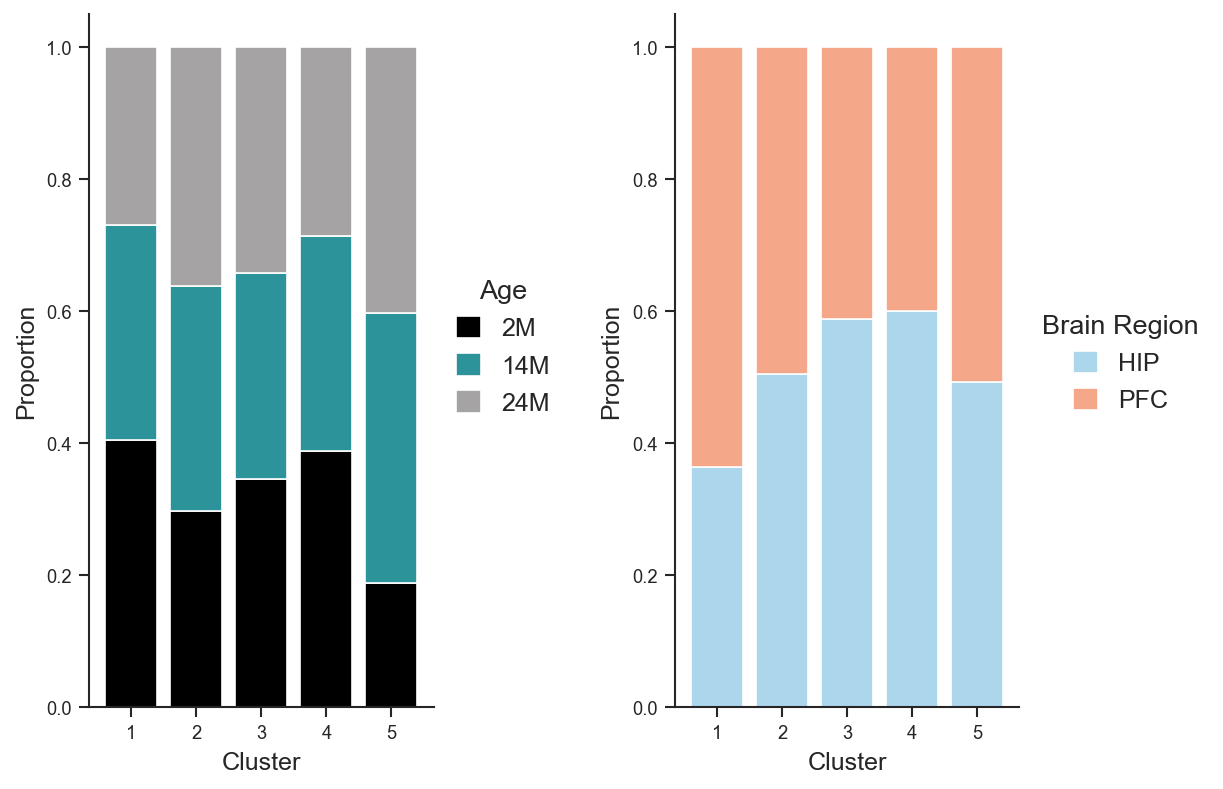

In [51]:
# plot age proportions in each leiden cluster  
leiden_clusters = np.sort(adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].unique())
age_groups = ['2M', '14M', '24M']  # Ensure consistent order of age groups
age_totals = adata_maxlfq_batch_corrected.obs['age'].value_counts()

age_proportions = pd.DataFrame(index=leiden_clusters, columns=age_groups)
for cluster in leiden_clusters:
    cluster_data = adata_maxlfq_batch_corrected.obs[adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'] == cluster]
    age_counts = cluster_data['age'].value_counts()
    normalized_counts = age_counts / age_totals
    age_proportions.loc[cluster] = normalized_counts / normalized_counts.sum()
    
age_proportions = age_proportions.fillna(0)

brain_regions = sorted(adata_maxlfq_batch_corrected.obs['brain_region'].dropna().unique())
brain_region_colors = ["#ACD6EC", "#F5A889"]

brain_region_totals = adata_maxlfq_batch_corrected.obs['brain_region'].value_counts()

brain_region_proportions = pd.DataFrame(index=leiden_clusters, columns=brain_regions)
for cluster in leiden_clusters:
    cluster_data = adata_maxlfq_batch_corrected.obs[adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'] == cluster]
    brain_region_counts = cluster_data['brain_region'].value_counts()
    normalized_counts = brain_region_counts / brain_region_totals
    brain_region_proportions.loc[cluster] = normalized_counts / normalized_counts.sum()

brain_region_proportions = brain_region_proportions.fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
age_proportions.plot(
    kind='bar',
    stacked=True,
    color=["#000000", "#2C939A", "#A6A3A4"],
    ax=axes[0],
    width=0.8,
)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Proportion', fontsize=12)
axes[0].legend(title='Age', bbox_to_anchor=(1, 0.65), frameon=False, handlelength=1, handleheight=1, fontsize=12, title_fontsize=13)

brain_region_proportions.plot(
    kind='bar',
    stacked=True,
    color=brain_region_colors,
    ax=axes[1],
    width=0.8,
)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
# ax.set_title('Brain Region Proportions in Each Leiden Cluster (Normalized)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].legend(title='Brain Region', bbox_to_anchor=(1, 0.6), handlelength=1, handleheight=1, frameon=False, fontsize=12, title_fontsize=13)

plt.subplots_adjust(wspace=0.7)
plt.savefig(fig_dir + f"age_proportions_by_cca_leiden_clusters.pdf", dpi=300, bbox_inches='tight')

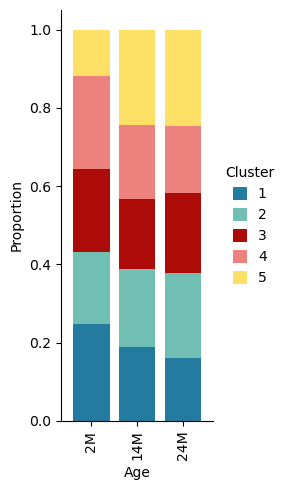

In [35]:
# plot leiden cluster composition in each age group
age_groups = [age for age in ['2M', '14M', '24M'] if age in adata_maxlfq_batch_corrected.obs['age'].unique()]
leiden_clusters = np.sort(adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].unique())
cluster_colors = ['#237B9F', '#71BFB2', '#AD0B08', '#EC817E', '#FEE066']

cluster_totals = adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].value_counts()

cluster_proportions_by_age = pd.DataFrame(index=age_groups, columns=leiden_clusters)
for age in age_groups:
    age_data = adata_maxlfq_batch_corrected.obs[adata_maxlfq_batch_corrected.obs['age'] == age]
    cluster_counts = age_data['cca_leiden_clusters'].value_counts()
    normalized_counts = cluster_counts / cluster_totals
    cluster_proportions_by_age.loc[age] = normalized_counts / normalized_counts.sum()

cluster_proportions_by_age = cluster_proportions_by_age.fillna(0)

fig, ax = plt.subplots(figsize=(3, 5))
cluster_proportions_by_age.plot(
    kind='bar',
    width=0.8,
    stacked=True,
    color=cluster_colors,
    ax=ax,
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Age')
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1, 0.65), frameon=False, handlelength=1, handleheight=1)
fig.tight_layout()
fig.savefig(fig_dir + "leiden_cluster_composition_by_age.pdf", dpi=300, bbox_inches='tight')

### Analysis of phagoproteome

In [4]:
adata_maxlfq_batch_corrected = sc.read_h5ad(results_dir + "scp_MG_1c_maxlfq_final_version.h5ad")

adata_maxlfq_exo = sc.read_h5ad('SCP_Microglia/results/1_3_preprocessing/scp_MG_1c_maxlfq_gene_after_qc_exo.h5ad')

In [5]:
adata_maxlfq_exo

AnnData object with n_obs × n_vars = 3068 × 320
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity'

In [6]:
cluster_mapping = adata_maxlfq_batch_corrected.obs['cca_leiden_clusters'].to_dict()
adata_maxlfq_exo.obs['cca_leiden_clusters'] = adata_maxlfq_exo.obs.index.map(cluster_mapping)

# 获取实际存在于 adata_maxlfq_exo.obs['cca_leiden_clusters'] 中的所有簇
unique_clusters = list(set(adata_maxlfq_exo.obs['cca_leiden_clusters'].dropna().unique()))
unique_clusters = [str(c) for c in unique_clusters if str(c) != 'nan' and str(c) != '5'] # 过滤掉不在列表里的或者将被去掉的 5 簇
unique_clusters.sort()

# order cca_leiden_clusters in adata_maxlfq_exo
adata_maxlfq_exo.obs['cca_leiden_clusters'] = adata_maxlfq_exo.obs['cca_leiden_clusters'].astype('category')
adata_maxlfq_exo.obs['cca_leiden_clusters'] = adata_maxlfq_exo.obs['cca_leiden_clusters'].cat.remove_unused_categories()

# 此时重新排列就不会因为缺少/多出原有 category 而报错了
adata_maxlfq_exo.obs['cca_leiden_clusters'] = adata_maxlfq_exo.obs['cca_leiden_clusters'].cat.reorder_categories([c for c in ['1', '2', '3', '4', '5'] if c in adata_maxlfq_exo.obs['cca_leiden_clusters'].cat.categories], ordered=True)

In [7]:
adata_maxlfq_exo = adata_maxlfq_exo[adata_maxlfq_exo.obs.cca_leiden_clusters != '5', :]

In [8]:
sc.pp.filter_genes(adata_maxlfq_exo, min_cells=10)

filtered out 77 genes that are detected in less than 10 cells


In [9]:
sample_metrics = sd.qc.calculate_cell_qc_metrics(adata_maxlfq_exo, inplace=True)
var_metrics = sd.qc.calculate_feature_qc_metrics(adata_maxlfq_exo, inplace=True)

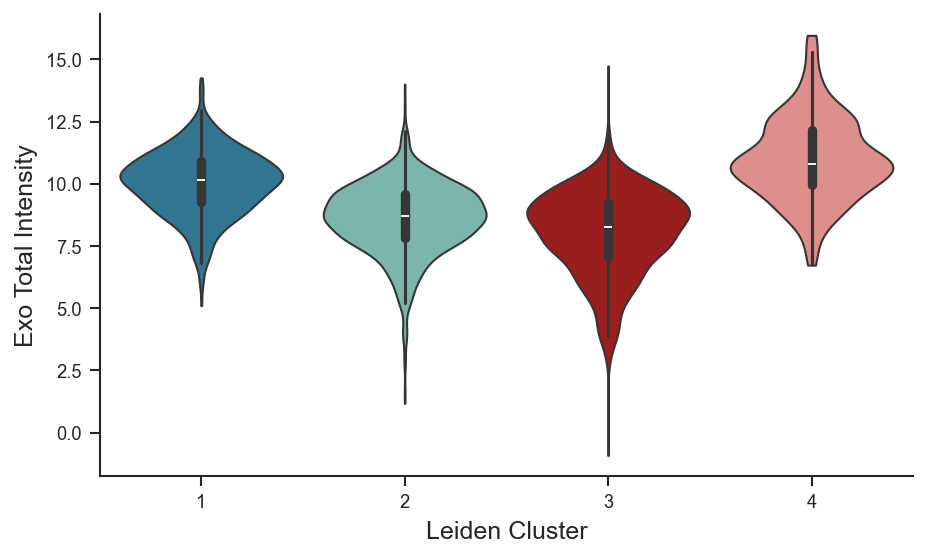

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))


sns.violinplot(
    adata_maxlfq_exo.obs,
    x='cca_leiden_clusters',
    y='log2_total_intensity',
    hue='cca_leiden_clusters',
    inner='box',
    ax=ax,
    palette=['#237B9F', '#71BFB2', '#AD0B08', '#EC817E'],
    cut=0.1
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Leiden Cluster', fontsize=12)
ax.set_ylabel('Exo Total Intensity', fontsize=12)

plt.savefig(fig_dir + "exo_total_intensity_by_leiden_cluster.pdf", dpi=300, bbox_inches='tight')

In [10]:
var_df = adata_maxlfq_exo.var.copy()
var_df = var_df.sort_values(by='pct_detected_cells', ascending=False)

In [11]:
adata_maxlfq_exo.obs['age_brain_region'] = adata_maxlfq_exo.obs['age'].astype(str) + '_' + adata_maxlfq_exo.obs['brain_region'].astype(str)

In [12]:
sc.pp.normalize_total(adata_maxlfq_exo)

sc.pp.log1p(adata_maxlfq_exo)

normalizing counts per cell
    finished (0:00:00)


In [13]:
adata_maxlfq_exo.layers['log2_total_normalized'] = adata_maxlfq_exo.X.copy()

In [14]:
# get expression df
df = pd.DataFrame(adata_maxlfq_exo.layers['log2_total_normalized'], index=adata_maxlfq_exo.obs.cca_leiden_clusters, columns=adata_maxlfq_exo.var_names).groupby(level=0).mean()
# scale columns
df = (df - df.mean(axis=0)) / df.std(axis=0)

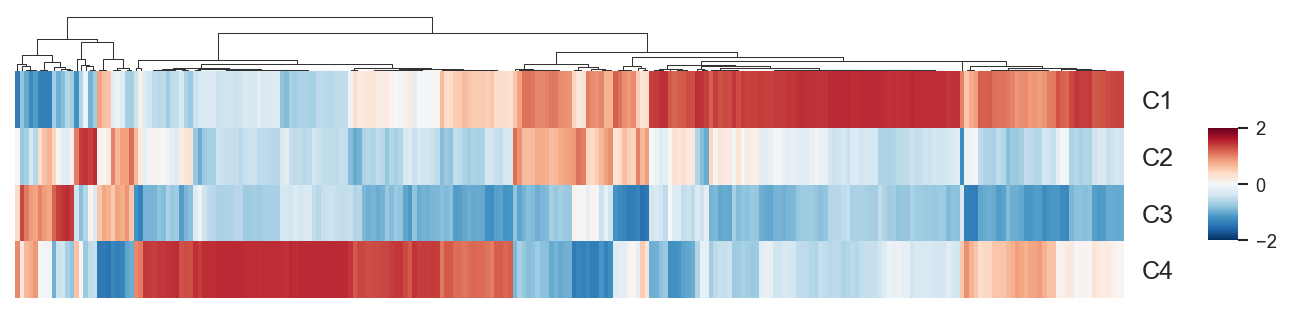

In [15]:
row_colors = ['#237B9F', '#71BFB2', '#AD0B08', '#EC817E']

g = sns.clustermap(
    df,
    row_cluster=False,
    col_cluster=True,
    cmap='RdBu_r',
    vmin=-2,
    vmax=2,
    method='average',
    metric='correlation',
    cbar_pos=(1.00, 0.45, 0.02, 0.25),
    figsize=(10, 3)
)

g.ax_row_dendrogram.set_visible(False)
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_yticklabels(['C1', 'C2', 'C3', 'C4'], rotation=0, fontsize=12)
g.ax_heatmap.tick_params(
    axis="both",
    bottom=False,
    top=False,
    left=False,
    right=False,
    labelbottom=False,
    labelleft=False
)

# g.savefig(fig_dir + "exo_clustermap.pdf", dpi=300, bbox_inches="tight")

In [16]:
import scipy.cluster.hierarchy as sch
import pandas as pd

# 获取 clustermap 中基因（这里是 df.T 的行）的层次聚类 linkage 矩阵
row_linkage = g.dendrogram_col.linkage

# 提取基因的原始顺序名称
genes = df.T.index

# 方法 1：按你想要的"具体簇的数量"来划分（比如我们想要划分成 5 个基因簇）
num_clusters = 4
cluster_labels = sch.fcluster(row_linkage, t=num_clusters, criterion='maxclust')

# 方法 2：按"距离阈值(resolution)"划分（可以根据你图上的树状图高度来调整 t 的大小）
# distance_threshold = 1.0 
# cluster_labels = sch.fcluster(row_linkage, t=distance_threshold, criterion='distance')

# 将基因与划分的簇对应起来
gene_clusters = pd.DataFrame({
    'Gene': genes,
    'Cluster': cluster_labels
})

# 按划分的簇进行排序，方便查看
gene_clusters = gene_clusters.sort_values(by='Cluster').reset_index(drop=True)

# 打印每个簇包含的基因数量
print(gene_clusters['Cluster'].value_counts())

# 查看结果
display(gene_clusters)

Cluster
4    134
3     83
1     13
2     13
Name: count, dtype: int64


,Gene,Cluster
0,Ptprn,1
1,Abca6,1
2,Gnb4,1
3,Acan,1
4,Rasgrp2,1
...,...,...
238,Uchl1,4
239,Lgi1,4
240,Lamc1,4
241,Pfkp,4


In [17]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
})

sns.set_theme(context='paper', style='ticks', rc={
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
})

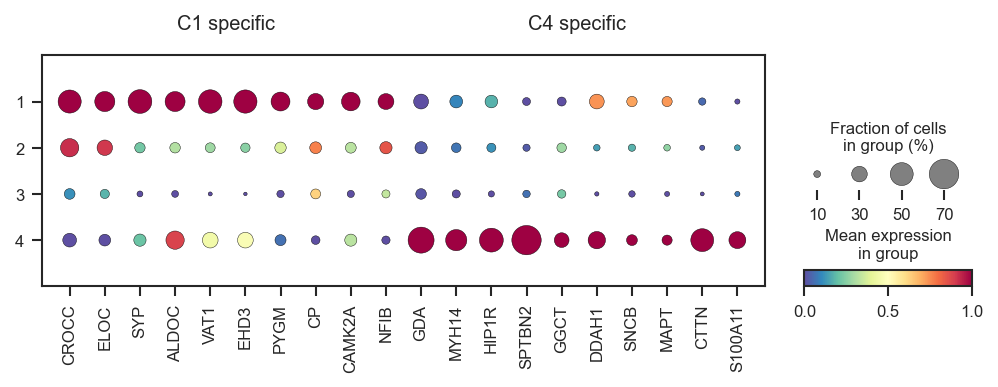

In [18]:
c3_genes = gene_clusters[gene_clusters['Cluster'] == 3]['Gene'].tolist()
c4_genes = gene_clusters[gene_clusters['Cluster'] == 4]['Gene'].tolist()


c3_top10 = [g for g in var_df.index if g in c3_genes][:10]
c4_top10 = [g for g in var_df.index if g in c4_genes][:10]

plot_genes = {'C1 specific': c4_top10, 'C4 specific': c3_top10}

dp = sc.pl.dotplot(
    adata_maxlfq_exo,
    var_names=plot_genes,
    groupby='cca_leiden_clusters',
    layer='log2_total_normalized',
    standard_scale='var',
    cmap='Spectral_r',
    figsize=(8, 2),
    var_group_rotation=0,
    return_fig=True
)

main_ax = dp.get_axes()['mainplot_ax']
main_ax.set_xticklabels([label.get_text().upper() for label in main_ax.get_xticklabels()])

plt.savefig(fig_dir + "dotplot_c3_c4_top10.pdf", dpi=300, bbox_inches='tight')
plt.show()